In [1]:
from typing import List,Annotated
import os
from pydantic import BaseModel

from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chat_models import init_chat_model
from langchain_community.document_loaders import WebBaseLoader
from langchain_classic.schema import Document

from langgraph.graph import StateGraph,START,END

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = init_chat_model(
    model="openai/gpt-oss-120b",
    model_provider="groq"
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000026F7F642660>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000026F7F643380>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [4]:
urls = [
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
    "https://lilianweng.github.io/posts/2023-06-23-agent/"
]
loaders = [ WebBaseLoader(url) for url in urls]
docs = []
for loader in loaders:
    docs.extend(loader.load())

docs    
    

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/', 'title': "Adversarial Attacks on LLMs | Lil'Log", 'description': 'The use of large language models in the real world has strongly accelerated by the launch of ChatGPT. We (including my team at OpenAI, shoutout to them) have invested a lot of effort to build default safe behavior into the model during the alignment process (e.g. via RLHF). However, adversarial attacks or jailbreak prompts could potentially trigger the model to output something undesired.\nA large body of ground work on adversarial attacks is on images, and differently it operates in the continuous, high-dimensional space. Attacks for discrete data like text have been considered to be a lot more challenging, due to lack of direct gradient signals. My past post on Controllable Text Generation is quite relevant to this topic, as attacking LLMs is essentially to control the model to output a certain type of (unsafe) content.', 'la

In [5]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50
)
chunks = splitter.split_documents(docs)
embedding = HuggingFaceEmbeddings()
vectorestore = FAISS.from_documents(chunks,embedding)
retriever = vectorestore.as_retriever()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [6]:
class Ragstate(BaseModel):
    question:str
    retrieved_docs:List[Document] = []
    answer:str = ""

In [8]:
def retrieved_docs(state:Ragstate) -> Ragstate:
    docs = retriever.invoke(state.question)
    return Ragstate(question=state.question,retrieved_docs=docs)

def generate_answer(state:Ragstate) -> Ragstate:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"Answer the question based on the context.\n\nContext:\n{context}\n\nQuestion: {state.question}"
    response = llm.invoke(prompt)
    return Ragstate(question=state.question,retrieved_docs=state.retrieved_docs,answer=response.content)
    

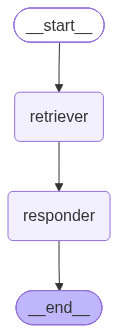

In [9]:
builder = StateGraph(Ragstate)

builder.add_node("retriever",retrieved_docs)
builder.add_node("responder",generate_answer)

builder.set_entry_point("retriever")
builder.add_edge("retriever","responder")
builder.add_edge("responder",END)

graph = builder.compile()
graph

In [11]:
result = graph.invoke(
    {
        "question": "What is an AI agent?"
    }
)

print("ANSWER:")
print(result["answer"])

print("\nRETRIEVED DOCUMENTS:")
for i, doc in enumerate(result["retrieved_docs"], 1):
    print(f"\n--- Document {i} ---")
    print(doc.page_content)

ANSWER:
An **AI agent** (in the sense of the LLM‑powered autonomous agents described by Lilian Weng) is a software entity that uses a large language model as its “brain” to perceive its environment, reason about goals, and take actions on its own.  

Key characteristics of such an agent include:

* **Autonomy** – it decides what to do without human step‑by‑step instruction.  
* **Planning** – it can decompose a large objective into sub‑goals, generate step‑by‑step plans, and refine those plans through self‑reflection and criticism.  
* **Memory** – it stores and retrieves information from past interactions or observations to maintain continuity over time.  
* **Tool use** – it can call external APIs, run code, fetch up‑to‑date data, or access proprietary resources that are not encoded in the model’s weights.  
* **Interaction** – it can communicate with other agents or humans, enabling multi‑agent simulations like the “Generative Agents” sandbox where dozens of characters behave believ